In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
import seaborn as sns

In [3]:
x = np.random.random(10000)
y = np.sqrt(1+x)

In [4]:
ones = np.ones(x.shape[0])[:,np.newaxis]

In [5]:
# Concat vector of ones 
X = np.concatenate([ones,x[:,np.newaxis]],axis = 1)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

In [7]:
w_closed = np.linalg.inv(X_train.T.dot(X_train)).dot(X_train.T).dot(y_train)

In [8]:
def loss(X,y,w):
    return np.mean((X.dot(w)-y)**2)
    

# Loss for closed form solution

In [8]:
trainloss = loss(X_train,y_train,w_closed)
valloss = loss(X_val,y_val,w_closed)
testloss = loss(X_test,y_test,w_closed)

In [9]:
print("Train loss: {}".format(trainloss))
print("Val loss: {}".format(valloss))
print("Test loss: {}".format(testloss))


Train loss: 2.7392586010164962e-05
Val loss: 2.7556206606240127e-05
Test loss: 2.6972933795157777e-05


In [10]:
w_closed

array([1.01307546, 0.41165499])

# Stochastic Gradient Descent

In [11]:
class StochasticGradDescent:
    def __init__(self, alpha = 1e-3, n_epochs = 100, eps = 1e-8):
        self.alpha = alpha
        self.n_epochs = n_epochs
        self.eps = eps
    def train(self,X,y):
        self.w = np.random.uniform(-1,1,X.shape[1])
        ep = 0
        w_cur = self.w
        diff = 1e6
        while (ep<self.n_epochs) and (diff>self.eps):
            print("Epoch: {}, Loss: {}".format(ep,loss(X,y,w_cur)))
            ind = np.arange(X.shape[0])
            np.random.shuffle(ind)
           
            for i in ind:
                w_new = w_cur-self.alpha*(2*(X[i,np.newaxis].T.dot(X[i,np.newaxis]).dot(w_cur)-X[i].T.dot(y[i])))
                diff = np.linalg.norm(w_new - w_cur)
                w_cur = w_new
            
            ep+=1
           
        self.w = w_cur
        self.loss = loss(X,y,self.w)
        
        

In [12]:
sgd = StochasticGradDescent(alpha = 1e-3,n_epochs=15)

In [13]:
sgd.train(X_train,y_train)

Epoch: 0, Loss: 1.4223707511885533
Epoch: 1, Loss: 0.005219384988231966
Epoch: 2, Loss: 0.0010899625925474734
Epoch: 3, Loss: 0.00024342131445966475
Epoch: 4, Loss: 7.195807926810229e-05
Epoch: 5, Loss: 3.663267595254274e-05
Epoch: 6, Loss: 2.9233265607982507e-05
Epoch: 7, Loss: 2.7852735551133426e-05
Epoch: 8, Loss: 2.7503849136639154e-05
Epoch: 9, Loss: 2.7413813833601814e-05
Epoch: 10, Loss: 2.739678636206702e-05
Epoch: 11, Loss: 2.7392876036387012e-05
Epoch: 12, Loss: 2.739530865322173e-05
Epoch: 13, Loss: 2.739261736808819e-05
Epoch: 14, Loss: 2.7403556985466902e-05


In [14]:
w_sgd = sgd.w
sgd.w

array([1.01296198, 0.41162216])

# Mini Batch Gradient Descent

In [15]:
class MiniBatchGradDescent:
    def __init__(self, alpha = 1e-3,batch_size = 10, n_epochs = 100, eps = 1e-8):
        self.alpha = alpha
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.eps = eps
    def train(self,X,y):
        self.w = np.random.uniform(-1,1,X.shape[1])
        ep = 0
        w_cur = self.w
        diff = 1e6
        while (ep<self.n_epochs) and (diff>self.eps):
            print("Epoch: {}, Loss: {}".format(ep,loss(X,y,w_cur)))
            ind = np.arange(X.shape[0])
            np.random.shuffle(ind)
            for i in range(0,X.shape[0],self.batch_size):
                if i+self.batch_size>X.shape[0]:
                    batch = ind[i:]
                else:
                    batch = ind[i:(i+self.batch_size)]
                w_new = w_cur-self.alpha*(2*(X[batch].T.dot(X[batch]).dot(w_cur)-X[batch].T.dot(y[batch])))
                diff = np.linalg.norm(w_new - w_cur)
                w_cur = w_new
            ep+=1
        self.w = w_cur
        self.loss = loss(X,y,self.w)
        
        

In [16]:
mbgd = MiniBatchGradDescent(alpha = 1e-3,n_epochs=15,batch_size=10)


In [17]:
mbgd.train(X_train,y_train)

Epoch: 0, Loss: 2.028802600066234
Epoch: 1, Loss: 0.0008153353526978691
Epoch: 2, Loss: 0.00018816649595606476
Epoch: 3, Loss: 6.021730937044193e-05
Epoch: 4, Loss: 3.416267577973715e-05
Epoch: 5, Loss: 2.8843479964993553e-05
Epoch: 6, Loss: 2.768089208612066e-05
Epoch: 7, Loss: 2.745189195047522e-05
Epoch: 8, Loss: 2.74048272938864e-05
Epoch: 9, Loss: 2.7398018294223606e-05
Epoch: 10, Loss: 2.746267445763287e-05
Epoch: 11, Loss: 2.7426352167650793e-05
Epoch: 12, Loss: 2.7426147128665955e-05
Epoch: 13, Loss: 2.7401908003032067e-05
Epoch: 14, Loss: 2.7407178787676874e-05


In [18]:
w_mbgd = mbgd.w

In [19]:
mbgd.w

array([1.01286297, 0.411419  ])

# Loss for gradient descent

In [20]:
xaxis = np.linspace(0,1,10000)

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/usr/local/lib/python3.7/dist-package

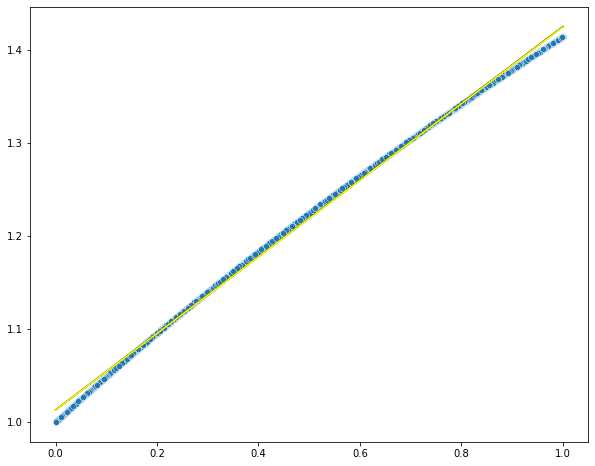

In [21]:
fig,ax = plt.subplots(figsize=(10,8))
sns.scatterplot(X[:,1],y,ax=ax)
sns.lineplot(xaxis,w_closed[0]+w_closed[1]*xaxis,color = "red")
sns.lineplot(xaxis,w_sgd[0]+w_sgd[1]*xaxis,color = "green")
sns.lineplot(xaxis,w_mbgd[0]+w_mbgd[1]*xaxis,color = "yellow")

plt.show()

In [22]:
print("Closed from solution: w0 = {}, w1 = {}".format(*w_closed))
print("Stochatic gradient descent solution: w0 = {}, w1 = {}".format(*w_sgd))
print("Mini batch gradient descent solution: w0 = {}, w1 = {}".format(*w_mbgd))

Closed from solution: w0 = 1.0130754627091174, w1 = 0.41165498900548253
Stochatic gradient descent solution: w0 = 1.01296198130924, w1 = 0.41162216329804147
Mini batch gradient descent solution: w0 = 1.0128629744292112, w1 = 0.4114190013595393


## We have all of the solution very close to each other

## Taylor first order approximation for $\sqrt{1+x}$ at 0 is $1+\frac{1}{2}x$ and is accurate when we take a look at values which are pretty close to 0
## In our case for values around 1 the Taylor approximation is not very accurate 
## Doing linear regression it tries to be close also for that values, so the line inclines towards that direction and the slope decreases a little bit 
## If we took not the range [0,1] but [0,0.1] the linear regression result would be much closer to Taylor first order approximation